In [29]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langgraph.types import Send
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os
import operator

In [30]:
load_dotenv()
OPEN_ROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

In [31]:
model = ChatOpenAI(
    api_key=OPEN_ROUTER_API_KEY,
    base_url= "https://openrouter.ai/api/v1",
    model = "openai/gpt-4o-mini"
)

In [32]:
class Task(BaseModel):
    goal: str
    instruction: str

In [33]:
class Assignment(BaseModel):
    tasks: list[Task]

In [34]:
llm_for_orchestration = model.with_structured_output(Assignment)

In [35]:
class State(TypedDict):
    topic: str
    assignment: Assignment
    result: Annotated[list[str], operator.add]

In [36]:
def orchestrator_node(state: State):
    topic = state['topic']
    assignment = llm_for_orchestration.invoke(
        f"""You are an orchestrator. 
        Given the topic '{topic}', 
        please create a list of tasks with clear goals and instructions.
    """)

    
    return {'assignment': assignment}

In [37]:
def fanout(state: State):
    return [Send("worker", {'topic': state['topic'], 'task': task}) for task in state['assignment'].tasks]

In [38]:
def worker(assignment_info: dict):
    user_topic = assignment_info['topic']
    task = assignment_info['task']
    goal = task.goal
    instruction = task.instruction

    result = f"I will implement the goal '{goal}' under the given instruction '{instruction}' for user request [{user_topic}]"

    return {'result': [result]}

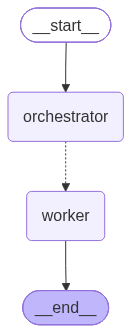

In [39]:
graph = StateGraph(State)

graph.add_node('orchestrator', orchestrator_node)
graph.add_node('worker', worker)

graph.add_edge(START, 'orchestrator')
graph.add_conditional_edges('orchestrator', fanout, ['worker'])
graph.add_edge('worker', END)

workflow = graph.compile()
workflow


In [40]:
config = {
    'configurable': {
        'thread_id': 'default'
    }
}

In [ ]:
output = workflow.invoke({'topic': 'Check this financial statement for loan allowance. [Assume Mock statement file as uploaded one]'}, config=config)

In [42]:
output

{'topic': 'Check this financial statement for loan allowance. [Assume Mock statement file as uploaded one]',
 'assignment': Assignment(tasks=[Task(goal='Identify total loan amounts in the financial statement', instruction='Review the uploaded financial statement and locate the section that lists total loan amounts. Make a note of each loan type and corresponding amounts.'), Task(goal='Determine the loan allowance based on accounting standards', instruction='Research the relevant accounting standards (such as GAAP or IFRS) regarding loan allowances. Summarize how these standards relate to the total loan amounts identified.'), Task(goal='Calculate the required loan allowance based on risk assessments', instruction='Using the total loan amounts and any available risk assessments provided in the financial statement, calculate the necessary loan allowance. Document your calculation process clearly.'), Task(goal='Verify accuracy of loan allowance calculations', instruction='Cross-check your 

In [49]:
for index, task in enumerate(output['assignment'].tasks):
    print(f"Worker {index} \n\n Goal: \n{task.goal} \n Instruction: \n{task.instruction} \n")
    print("="*20)

Worker 0 

 Goal: 
Identify total loan amounts in the financial statement 
 Instruction: 
Review the uploaded financial statement and locate the section that lists total loan amounts. Make a note of each loan type and corresponding amounts. 

Worker 1 

 Goal: 
Determine the loan allowance based on accounting standards 
 Instruction: 
Research the relevant accounting standards (such as GAAP or IFRS) regarding loan allowances. Summarize how these standards relate to the total loan amounts identified. 

Worker 2 

 Goal: 
Calculate the required loan allowance based on risk assessments 
 Instruction: 
Using the total loan amounts and any available risk assessments provided in the financial statement, calculate the necessary loan allowance. Document your calculation process clearly. 

Worker 3 

 Goal: 
Verify accuracy of loan allowance calculations 
 Instruction: 
Cross-check your calculated loan allowance with any allowances previously noted in the financial statement. Ensure that calcul